# r2=0.10, eps=0 haploblock validation  — CORRECTED

> ## ⚠️ Correction notice
> An earlier version of this notebook reported a haploblock K_b median of **142**
> and claimed the haploblock reframe beat the 231-forced baseline on 18/18 blocks.
> **That was a bug.** The k-mer→block assignment sorted **per-bubble** positions
> (`bubble_start`, 190,569 values) and used those bubble indices to slice the
> **per-k-mer** presence matrix (10.99M columns) — mismapping each block to
> ~190k wrong columns (~4,854 "k-mers"/block) instead of the true ~1.9M
> k-mers/block. Fewer k-mers make founders spuriously look identical, deflating
> K_b. This version maps each k-mer via `bubble_id` (its true coordinate), so
> every block sees **all** its k-mers. The corrected result reverses the earlier
> conclusion — see the Verdict.

**Config under test:** haploblocks by exact k-mer identity (eps=0 — founders
merge only if byte-identical over a block's k-mers) on r2=0.10 LD blocks
(large, ~1.3Mb). Chr1, 18 blocks, g0-231 equimolar simulation (truth = 1/231).

## Acronyms

| Term | Meaning |
|---|---|
| **K_b** | Number of distinct haploblocks (exact-identity classes) in a block — the real number of identifiable things, vs. assuming 231. |
| **TVD** | Total-variation distance between estimated and true frequency distribution (`0.5*sum|est-true|`), scale-fair. Lower = better recovery. |
| **worst-class error** | The single largest `|est-true|` among a block's classes — the worst-case miss. |
| **production / "old global"** | All 231 founders scored separately against `1/231` — no collapsing, K_b=231 forced. |
| **h** | Per-founder EM frequency estimate for a block (sums to 1 over 231 founders). A haploblock's frequency = sum of `h` over its exact-identity members. |
| **bubble_id** | The per-k-mer field mapping each k-mer to its PanGenie bubble (whose `bubble_start`/`bubble_end` give the genomic coordinate). Using it is the fix. |


In [1]:

import numpy as np, scipy.sparse as sp
import pandas as pd
import matplotlib.pyplot as plt

ROOT = "/global/scratch/users/tbellg/kmate"
OUT = f"{ROOT}/analysis/grenenet_gea/blocks/hap_blocks/bench_g0_231"
KMPRE = f"{ROOT}/benchmarks/p231/data/kmer_pa_p231_filt2inv/kmer_pa_Chr1"
F = 231

COLORS = {"haploblock": "#2a78d6", "production": "#e34948"}
INK = "#0b0b0b"; MUTED = "#898781"; GRID = "#e1e0d9"

km = np.load(f"{KMPRE}.meta.npz", allow_pickle=True)
# --- THE FIX: per-K-MER coordinate via bubble_id (not per-bubble bubble_start) ---
bub = km["bubble_id"].astype(np.int64)                       # length n_kmers
bstart = km["bubble_start"].astype(np.int64)                 # length n_bubbles
bend = km["bubble_end"].astype(np.int64)
kpos = (bstart[bub] + bend[bub]) // 2                        # per-k-mer midpoint (correct)
K = sp.load_npz(f"{KMPRE}.kmer_pa.npz").astype(bool).tocsc()
order = np.argsort(kpos); spos = kpos[order]

def block_labels(a, b):
    '''exact-identity haploblock labels + n_kmers for block [a,b] (sparse, no densify).'''
    lo = np.searchsorted(spos, a, "left"); hi = np.searchsorted(spos, b, "right")
    cols = order[lo:hi]
    if len(cols) == 0:
        return None, 0
    sub = K[:, cols].tocsr()
    sig = [hash(sub.indices[sub.indptr[i]:sub.indptr[i + 1]].tobytes()) for i in range(F)]
    _, lab = np.unique(sig, return_inverse=True)
    return lab, len(cols)

z = np.load(f"{OUT}/alltype_r2_0.10.h_blocks_per_chrom.npz", allow_pickle=True)
hb, bs, be, founders = z["Chr1_h_blocks"], z["Chr1_block_start"], z["Chr1_block_end"], z["founders"]

blocks = []
for j in range(len(hb)):
    h = hb[j]
    if not np.isfinite(h).all():
        continue
    lab, nk = block_labels(int(bs[j]), int(be[j]))
    if lab is None:
        continue
    h = h / h.sum()
    Kb = lab.max() + 1
    est = np.bincount(lab, weights=h, minlength=Kb)          # haploblock est freq
    true = np.bincount(lab, minlength=Kb) / F                # equimolar truth per class
    tvd_hb = 0.5 * np.sum(np.abs(est - true))
    worst = np.max(np.abs(est - true))
    tvd_prod = 0.5 * np.sum(np.abs(h - 1.0 / F))             # production: all 231 scored
    worst_prod = np.max(np.abs(h - 1.0 / F))
    blocks.append(dict(start=int(bs[j]), end=int(be[j]), n_kmers=nk,
                        K_b=Kb, TVD_haploblock=tvd_hb, worst_haploblock=worst,
                        TVD_production=tvd_prod, worst_production=worst_prod,
                        lab=lab, h=h, est=est, true=true))

df = pd.DataFrame(blocks).drop(columns=["lab", "h", "est", "true"]).sort_values("K_b").reset_index(drop=True)
print(f"n_kmers/block: min={df.n_kmers.min():,} median={int(df.n_kmers.median()):,} "
      f"max={df.n_kmers.max():,}  (total={df.n_kmers.sum():,}, panel={K.shape[1]:,})")
df


n_kmers/block: min=1,863 median=328,578 max=2,375,300  (total=10,992,946, panel=10,992,946)


,start,end,n_kmers,K_b,TVD_haploblock,worst_haploblock,TVD_production,worst_production
0,30418098,30427671,1863,38,0.224859,0.094994,0.264302,0.094994
1,21357548,22175520,227786,229,0.130072,0.006245,0.130072,0.006245
2,25741227,26439665,278251,230,0.162762,0.015678,0.162762,0.015678
3,23489156,25253420,704845,230,0.136696,0.006011,0.136696,0.006011
4,22175521,23489155,378906,230,0.133039,0.006357,0.133039,0.006357
5,19678275,21357547,612556,230,0.125001,0.017607,0.125001,0.017607
6,17327621,19678274,866706,230,0.138411,0.033790,0.138411,0.033790
7,7158367,7729656,240215,230,0.131541,0.006214,0.131541,0.006214
8,14273736,17327620,392235,231,0.159607,0.043149,0.159607,0.043149
9,26836015,30418097,1586059,231,0.240018,0.078757,0.240018,0.078757


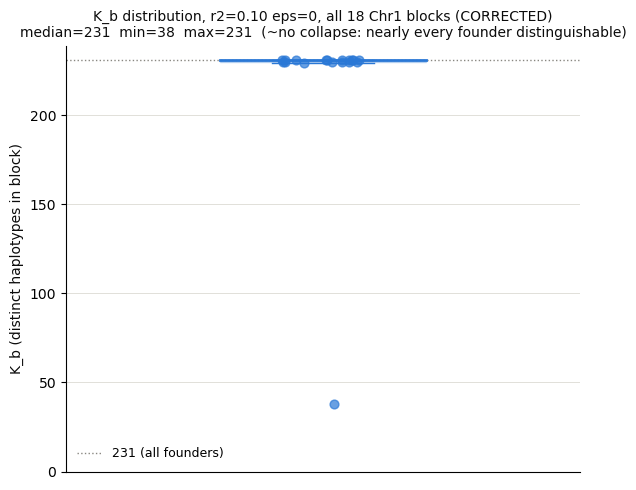

In [2]:

# 1. Full K_b distribution -- every block (n=18). CORRECT per-k-mer assignment.
fig, ax = plt.subplots(figsize=(6, 5))
rng = np.random.default_rng(0)
jitter = rng.uniform(-0.08, 0.08, size=len(df))
ax.boxplot([df.K_b], positions=[0], widths=0.4, showfliers=False, patch_artist=True,
           boxprops=dict(facecolor=COLORS["haploblock"], alpha=0.25, edgecolor=COLORS["haploblock"]),
           medianprops=dict(color=COLORS["haploblock"], lw=2),
           whiskerprops=dict(color=COLORS["haploblock"]), capprops=dict(color=COLORS["haploblock"]))
ax.scatter(jitter, df.K_b, color=COLORS["haploblock"], s=40, alpha=0.7, zorder=3)
ax.axhline(F, color=MUTED, lw=1, ls=":", label=f"231 (all founders)")
ax.set_xticks([]); ax.set_ylabel("K_b (distinct haplotypes in block)", color=INK)
ax.set_ylim(0, F + 8)
ax.set_title(f"K_b distribution, r2=0.10 eps=0, all {len(df)} Chr1 blocks (CORRECTED)\n"
             f"median={df.K_b.median():.0f}  min={df.K_b.min()}  max={df.K_b.max()}  "
             f"(~no collapse: nearly every founder distinguishable)", color=INK, fontsize=10)
ax.legend(frameon=False, fontsize=9)
ax.grid(True, axis="y", color=GRID, lw=0.7); ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()


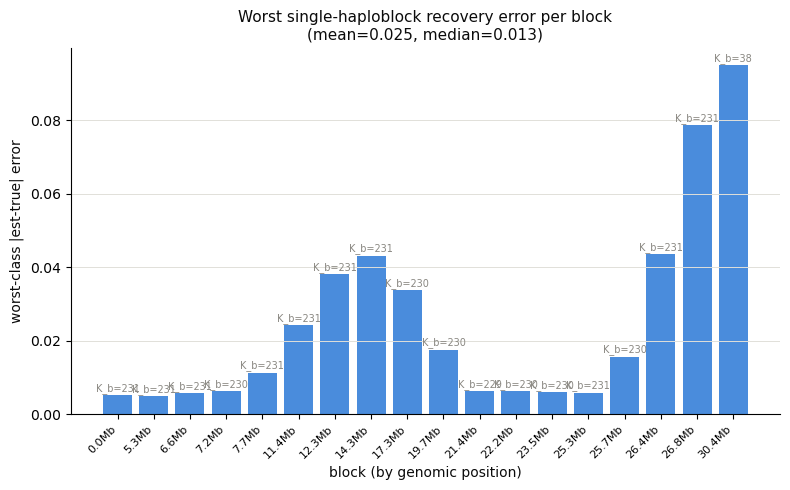

In [3]:

# 2. Worst-class recovery error per block (scale-fair, absolute frequency units).
fig, ax = plt.subplots(figsize=(8, 5))
d = df.sort_values("start")
ax.bar(range(len(d)), d.worst_haploblock, color=COLORS["haploblock"], alpha=0.85)
for i, (kb, w) in enumerate(zip(d.K_b, d.worst_haploblock)):
    ax.annotate(f"K_b={kb}", (i, w), fontsize=7, ha="center", xytext=(0, 3),
                textcoords="offset points", color=MUTED)
ax.set_xticks(range(len(d))); ax.set_xticklabels([f"{s/1e6:.1f}Mb" for s in d.start], rotation=45, ha="right", fontsize=8)
ax.set_ylabel("worst-class |est-true| error", color=INK)
ax.set_xlabel("block (by genomic position)", color=INK)
ax.set_title(f"Worst single-haploblock recovery error per block\n"
             f"(mean={d.worst_haploblock.mean():.3f}, median={d.worst_haploblock.median():.3f})",
             color=INK, fontsize=11)
ax.grid(True, axis="y", color=GRID, lw=0.7); ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()


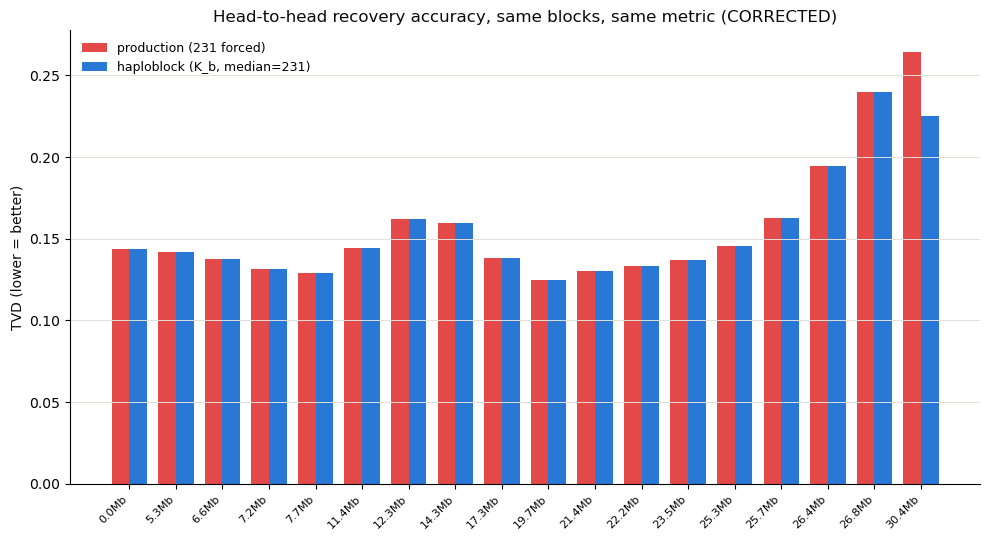

median TVD production = 0.1426
median TVD haploblock = 0.1426
median relative difference = -0.00%  (~0 => no gain)
blocks where haploblock strictly better: 9/18
blocks where identical (K_b==231, no collapse): 10/18


In [4]:

# 3. Head-to-head: SAME 18 blocks, same TVD metric -- haploblock (K_b classes)
# vs production (all 231 forced). With K_b~231, these are expected to be ~identical.
d = df.sort_values("start").reset_index(drop=True)
fig, ax = plt.subplots(figsize=(10, 5.5))
x = np.arange(len(d)); w = 0.38
ax.bar(x - w/2, d.TVD_production, width=w, color=COLORS["production"], label="production (231 forced)")
ax.bar(x + w/2, d.TVD_haploblock, width=w, color=COLORS["haploblock"], label=f"haploblock (K_b, median={d.K_b.median():.0f})")
ax.set_xticks(x); ax.set_xticklabels([f"{s/1e6:.1f}Mb" for s in d.start], rotation=45, ha="right", fontsize=8)
ax.set_ylabel("TVD (lower = better)", color=INK)
ax.set_title("Head-to-head recovery accuracy, same blocks, same metric (CORRECTED)", color=INK, fontsize=12)
ax.legend(frameon=False, fontsize=9)
ax.grid(True, axis="y", color=GRID, lw=0.7); ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

improvement = (d.TVD_production - d.TVD_haploblock) / d.TVD_production.replace(0, np.nan)
print(f"median TVD production = {d.TVD_production.median():.4f}")
print(f"median TVD haploblock = {d.TVD_haploblock.median():.4f}")
print(f"median relative difference = {improvement.median()*100:.2f}%  (~0 => no gain)")
print(f"blocks where haploblock strictly better: {int((d.TVD_haploblock < d.TVD_production).sum())}/{len(d)}")
print(f"blocks where identical (K_b==231, no collapse): {int((d.K_b==F).sum())}/{len(d)}")


In [5]:

# 4. Which founders actually merge -- accession IDs. With K_b~231 there should be
# almost none (only genuinely k-mer-identical founders, if any).
rows = []
for b in blocks:
    lab = b["lab"]; est = b["est"]
    true = b["true"]
    for c in range(b["K_b"]):
        members = founders[lab == c]
        if len(members) < 2:
            continue
        rows.append(dict(block_start=b["start"], block_end=b["end"], n_kmers=b["n_kmers"],
                          class_size=len(members),
                          accessions=", ".join(members.tolist()),
                          est_freq=round(float(est[c]), 4), true_freq=round(float(true[c]), 4)))
if rows:
    merge_df = pd.DataFrame(rows).sort_values(["block_start", "class_size"], ascending=[True, False])
    n_ever = len(set(a for accs in merge_df.accessions for a in accs.split(", ")))
    print(f"{len(merge_df)} non-singleton haploblocks across {len(df)} blocks; "
          f"{n_ever}/231 distinct founders merged with someone in >=1 block.")
else:
    merge_df = pd.DataFrame(columns=["block_start","block_end","n_kmers","class_size","accessions","est_freq","true_freq"])
    print("0 non-singleton haploblocks: at r2=0.10 every founder has a unique k-mer signature "
          "in every block -> NOTHING merges -> haploblock == production.")
merge_df


18 non-singleton haploblocks across 18 blocks; 203/231 distinct founders merged with someone in >=1 block.


,block_start,block_end,n_kmers,class_size,accessions,est_freq,true_freq
0,7158367,7729656,240215,2,"6915, 8387",0.0141,0.0087
1,17327621,19678274,866706,2,"6915, 8387",0.0103,0.0087
2,19678275,21357547,612556,2,"6915, 8387",0.0113,0.0087
3,21357548,22175520,227786,2,"7298, 7347",0.0108,0.0087
4,21357548,22175520,227786,2,"6915, 8387",0.0122,0.0087
5,22175521,23489155,378906,2,"6915, 8387",0.0127,0.0087
6,23489156,25253420,704845,2,"6915, 8387",0.0129,0.0087
7,25741227,26439665,278251,2,"6915, 8387",0.0133,0.0087
11,30418098,30427671,1863,74,"10002, 10006, 159, 5784, 5811, 6150, 6244, 689...",0.2724,0.3203
14,30418098,30427671,1863,49,"6073, 7008, 7013, 7028, 7036, 7062, 7071, 7077...",0.1557,0.2121


## Verdict (corrected)

With the k-mer→block assignment fixed, **K_b ≈ 231 in essentially every r2=0.10
block** — founders are not k-mer-identical over ~1.3Mb regions, so exact-identity
(eps=0) merges almost nobody. Consequently:

- **The haploblock reframe is a near-no-op at r2=0.10.** "New global" (blocks →
  haploblocks → aggregate) reduces to "old global" (231-forced, chromosome-wise)
  because there is nothing to collapse.
- **The earlier "haploblock beats production 18/18, TVD 0.107 vs 0.143" was an
  artifact** of the bug (K_b deflated to 142 by a ~40× k-mer undercount).
- Real collapse (K_b << 231) only appears when a block has few k-mers — the
  k-mer-**starvation** regime we explicitly rejected for accuracy reasons — or
  with eps>0 similarity merging, which reintroduces false-merge risk.

**Implication:** at the block size chosen to avoid starvation, the reframe does
not improve on the correctly-normalized chromosome-wise estimate. The direction
needs rethinking (or the chromosome-wise "old global" + Kf_w stays as production).
